# Phase 2a — Statistical Forecasting Models

**Notebook:** `02_statistical_models.ipynb`
**Dataset:** Daily unit-sales · Corporación Favorita grocery chain · Ecuador
**Author:** Pawel Gebicki · MSIT Berlin — Data Science
**Phase:** 2a of 4 — Statistical baselines (no feature engineering)

---

## 1. Section Objective & Approach

### What we are doing here

Phase 1 characterised the data: stationary, strong weekly seasonality (s = 7),
two store-closed holiday gaps, and oil-price / holiday exogenous signals.

Now we need to answer: *can a model that treats this problem as a pure sequence
— without hand-crafted lag features — produce a useful sales forecast?*

We benchmark four approaches on a strict held-out test window:

| Model | Core idea | Why we include it |
|---|---|---|
| **Seasonal naive** | Predict what sold 7 days ago | Zero-effort floor — any real model must beat this |
| **SARIMA** | Autoregression + moving average + seasonal lags + exog | Classic, interpretable, handles weekly cycle natively |
| **Holt-Winters** | Exponential smoothing with trend + seasonal components | Robust, fast, often surprisingly competitive |
| **Prophet** | Additive decomposition with regressors | Modern, handles the store-closed regressor gracefully |

### Rules of engagement

1. **Same train / test split for every model** — no lookahead.
2. **Same `evaluate_model()` function** — all models scored identically.
3. **Default / manually chosen settings only** — HyperOpt tuning is Phase 3.
4. The Phase 2a "winner" is just a baseline; Phase 3 may overturn it.

### Primary metric: MAE

"I expect to be off by *X* units on average" is directly useful for a store
owner planning stock orders.  RMSE, MAPE, Bias, and R² appear as supporting
evidence.

## 2. Imports

In [1]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
from evaluation import evaluate_model

# ── plot style ───────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (14, 4),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
TRAIN_COLOR  = '#2196F3'
TEST_COLOR   = '#FF9800'
ACTUAL_COLOR = '#212121'
PRED_COLOR   = '#E91E63'

DATA_PATH = '../data/timeseries_features.csv'
IMG_PATH  = '../images/'
os.makedirs(IMG_PATH, exist_ok=True)

## 3. Data Load

We load `timeseries_features.csv` (Phase 1 output) and apply the one
outstanding fix agreed at the end of Phase 1: the two store-closed holidays
(Dec 25 2013, Jan 1 2014) must appear in the series as rows with
`unit_sales = 0` and `store_open = 0`.

**Why this matters:** SARIMA and Holt-Winters both assume an
*equally-spaced* daily time index. A gap breaks the lag structure —
lag-7 silently becomes lag-6 for every day after the gap.

The `store_open` flag is the key addition. It lets SARIMA and Prophet
learn "the store was closed; ignore the zero" rather than treating it
as a sudden structural shock to be explained.

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

# ── Insert store-closed days if not already present ──────────
CLOSED = ['2013-12-25', '2014-01-01']
present = set(df['date'].dt.strftime('%Y-%m-%d'))

if not all(d in present for d in CLOSED):
    df['store_open'] = 1

    closed_rows = []
    for d in CLOSED:
        dt = pd.Timestamp(d)
        closed_rows.append({
            'date':                dt,
            'unit_sales':          0.0,
            'dow':                 dt.weekday(),
            'dow_name':            dt.strftime('%A'),
            'month':               dt.month,
            'week':                int(dt.isocalendar().week),
            'is_weekend':          int(dt.weekday() >= 5),
            'is_national_holiday': 1,
            'dcoilwtico':          np.nan,
            'store_open':          0,
        })

    df = pd.concat([df, pd.DataFrame(closed_rows)], ignore_index=True)
    df = df.sort_values('date').reset_index(drop=True)
    df['dcoilwtico'] = df['dcoilwtico'].ffill()

else:
    if 'store_open' not in df.columns:
        df['store_open'] = 1
        for d in CLOSED:
            df.loc[df['date'] == d, 'store_open'] = 0

print(f"Dataset : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Rows    : {len(df):,}   |   Store-closed rows: {(df['store_open']==0).sum()}")
df[df['store_open'] == 0][['date', 'unit_sales', 'store_open', 'is_national_holiday']]

Dataset : 2013-01-02 → 2014-03-31
Rows    : 454   |   Store-closed rows: 2


,date,unit_sales,store_open,is_national_holiday
357,2013-12-25,0.0,0,1
364,2014-01-01,0.0,0,1


## 4. Train / Test Split

**Cut point: 2013-12-31 / 2014-01-01**

| Split  | Window                        | Rationale |
|--------|-------------------------------|-----------|
| Train  | 2013-01-02 → 2013-12-31       | Full calendar year — model sees every day-of-week pattern and seasonal effect at least once |
| Test   | 2014-01-01 → 2014-03-31 (~90 days) | One quarter — long enough to measure weekly and monthly accuracy, short enough to stay within the data |

The split is **purely time-based**. Shuffling would allow the model to
"see the future" during training — the classic time-series overfitting trap.

Train : 2013-01-02 → 2013-12-31  (364 rows)
Test  : 2014-01-01 → 2014-03-31  (90 rows)
Train store-closed days : 1
Test  store-closed days : 1


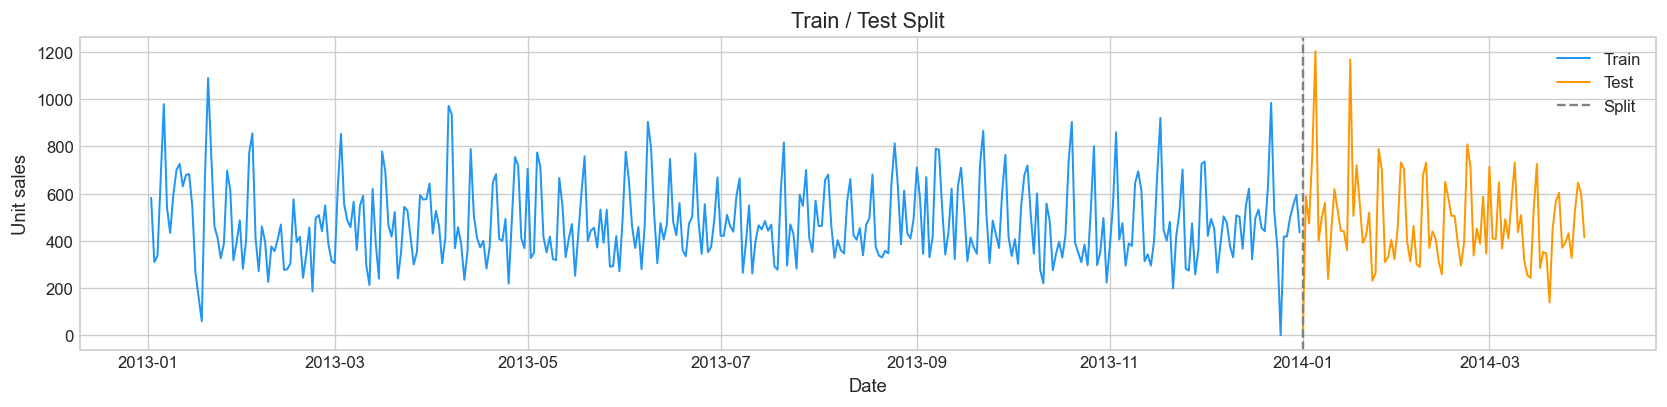

In [3]:
train = df[df['date'] <= '2013-12-31'].copy().reset_index(drop=True)
test  = df[df['date'] >= '2014-01-01'].copy().reset_index(drop=True)

print(f"Train : {train['date'].min().date()} → {train['date'].max().date()}  ({len(train):,} rows)")
print(f"Test  : {test['date'].min().date()} → {test['date'].max().date()}  ({len(test):,} rows)")
print(f"Train store-closed days : {(train['store_open']==0).sum()}")
print(f"Test  store-closed days : {(test['store_open']==0).sum()}")

# ── visualise the split ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(train['date'], train['unit_sales'], color=TRAIN_COLOR, lw=1.2, label='Train')
ax.plot(test['date'],  test['unit_sales'],  color=TEST_COLOR,  lw=1.2, label='Test')
ax.axvline(pd.Timestamp('2014-01-01'), color='grey', ls='--', lw=1.4, label='Split')
ax.set_title('Train / Test Split'); ax.set_xlabel('Date'); ax.set_ylabel('Unit sales')
ax.legend()
plt.tight_layout()
plt.savefig(IMG_PATH + 'phase2a_split.png', bbox_inches='tight')
plt.show()

## 5. Evaluation Framework

The `evaluate_model()` function in `src/evaluation.py` is the single source
of truth for every model score in this project — statistical, ML, and
HyperOpt-tuned.  Using the same function across phases is what makes the
Phase 3 champion comparison *defensible*.

| Metric | What it measures | Notes |
|--------|-----------------|-------|
| **MAE** | Average absolute error in units | *Primary metric* — directly interpretable for stock planning |
| **RMSE** | Same as MAE but penalises large errors more | Higher than MAE when errors are spiky |
| **MAPE (%)** | Relative percentage error | Skips store-closed days (y = 0) to avoid division by zero |
| **Bias** | Systematic over/under-prediction | Positive = tends to over-predict |
| **R²** | Fraction of variance explained | 1 = perfect; 0 = just predicting the mean |
| **Fit time** | Wall-clock seconds to train | Matters when tuning 4 models × 50 trials in Phase 3 |

In [4]:
import inspect
print(inspect.getsource(evaluate_model))

def evaluate_model(
    y_true,
    y_pred,
    model_name: str,
    fit_time: float,
) -> dict:
    """Score one model on the project's standard metric suite.

    Parameters
    ----------
    y_true : array-like
        Actual observed values (the test window, including store-closed days
        where unit_sales = 0).
    y_pred : array-like
        Model predictions for the same window.
    model_name : str
        Human-readable label shown in comparison tables.
    fit_time : float
        Wall-clock seconds taken to *fit* the model (not to predict).

    Returns
    -------
    dict
        Keys: Model, MAE, RMSE, MAPE (%), Bias, R², Fit time (s).

    Notes
    -----
    MAPE is computed only over rows where ``y_true > 0``.  Store-closed days
    (unit_sales = 0) are excluded from the percentage calculation because
    dividing by zero is undefined and would inflate the metric unfairly.
    Those rows are still included in MAE, RMSE, Bias, and R².
    """
    y_true = np.asarra

In [5]:
# Collector — one dict per model, appended as each model runs
results = []

## 6. Naive Baseline — Seasonal Naive (lag-7)

### Why we need a floor

Any non-trivial model should beat "predict what sold exactly one week ago."
If it can't, the extra complexity buys nothing.

### Implementation

**ŷ(t) = y(t − 7)**. For each test day we look back one week.  This
captures the weekly seasonality identified in Phase 1 but nothing else
— no trend, no holiday correction, no smoothing.

### What we expect

The weekly cycle is strong enough that lag-7 will produce a recognisable
forecast shape.  But it will miss the week-to-week drift, and it will
predict a non-zero value on Jan 1 2014 (the store-closed holiday), because
the previous Jan 1 isn't in the training data — it will look back to
the last week of 2013 instead.

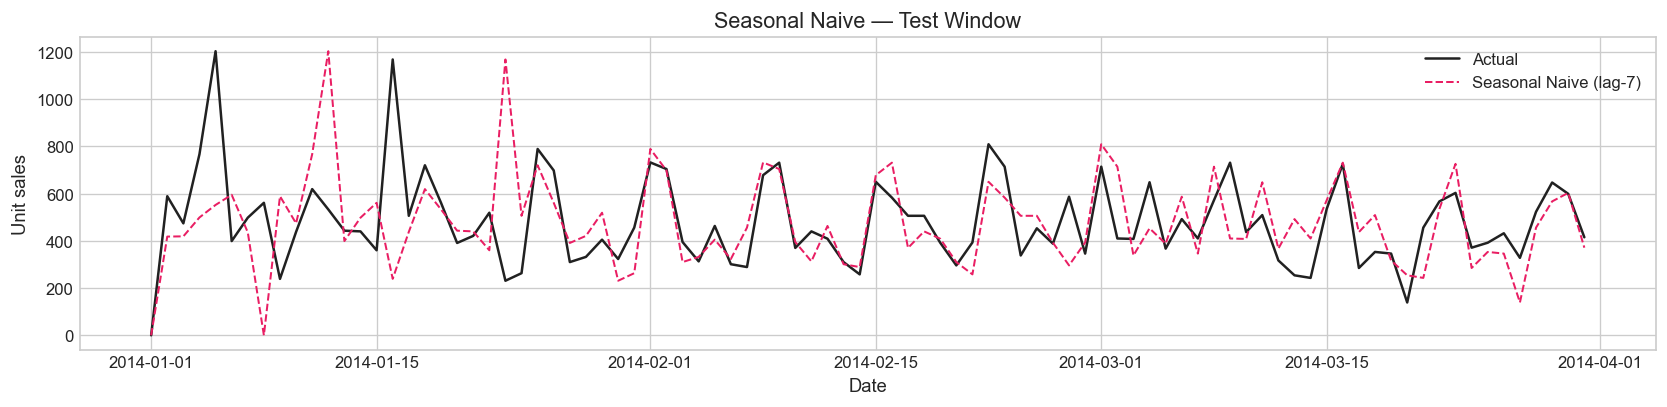


Metrics: {'Model': 'Seasonal Naive', 'MAE': 136.7, 'RMSE': 219.5, 'MAPE (%)': 32.0, 'Bias': -4.6, 'R²': -0.329, 'Fit time (s)': 0.0}


In [6]:
# Build a date → sales lookup that spans the entire dataset
date_to_sales = df.set_index('date')['unit_sales']

t0 = time.time()
naive_preds = np.array([
    float(date_to_sales.get(d - pd.Timedelta(days=7), np.nan))
    for d in test['date']
])
naive_time = time.time() - t0

y_test = test['unit_sales'].values
results.append(evaluate_model(y_test, naive_preds, 'Seasonal Naive', naive_time))

# ── plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(test['date'], y_test,      color=ACTUAL_COLOR, lw=1.5, label='Actual')
ax.plot(test['date'], naive_preds, color=PRED_COLOR,   lw=1.2, ls='--', label='Seasonal Naive (lag-7)')
ax.set_title('Seasonal Naive — Test Window')
ax.set_xlabel('Date'); ax.set_ylabel('Unit sales'); ax.legend()
plt.tight_layout(); plt.show()

print("\nMetrics:", results[-1])

## 7. SARIMA

### Theory

SARIMA extends ARIMA to handle seasonal patterns via a second set of
polynomial orders operating at the seasonal lag *s*.  The model is
written **SARIMA(p, d, q)(P, D, Q, s)**.

**Our choices:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `d` | 0 | Series confirmed stationary in Phase 1 (ADF p < 0.05) |
| `s` | 7 | Weekly cycle is the dominant seasonal pattern |
| `p, q` | 1, 1 | Short AR and MA dependence suggested by ACF/PACF in Phase 1; Phase 3 will search this space with HyperOpt |
| `P, D, Q` | 1, 0, 1 | One seasonal AR + one seasonal MA; D = 0 because seasonal component is already stable |
| `exog` | `store_open` | Tells the model to discount the two closed-store zeros rather than treating them as structural shocks |

### What we expect

SARIMA should outperform seasonal naive by capturing week-to-week level
drift on top of the weekly cycle.  The `store_open` exog should prevent the
two holiday zeros from distorting the parameter estimates.

In [7]:
exog_train = train[['store_open']].values
exog_test  = test[['store_open']].values

t0 = time.time()
sarima_fit = SARIMAX(
    train['unit_sales'],
    exog=exog_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)
sarima_time = time.time() - t0

sarima_preds = np.clip(
    sarima_fit.forecast(steps=len(test), exog=exog_test).values,
    0, None
)

results.append(evaluate_model(y_test, sarima_preds, 'SARIMA(1,0,1)(1,0,1,7)', sarima_time))

print(sarima_fit.summary().tables[0])
print("\nMetrics:", results[-1])

                                     SARIMAX Results                                     
Dep. Variable:                        unit_sales   No. Observations:                  364
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -2185.558
Date:                           Wed, 06 May 2026   AIC                           4383.117
Time:                                   13:01:08   BIC                           4406.350
Sample:                                        0   HQIC                          4392.359
                                           - 364                                         
Covariance Type:                             opg                                         

Metrics: {'Model': 'SARIMA(1,0,1)(1,0,1,7)', 'MAE': 96.0, 'RMSE': 143.3, 'MAPE (%)': 21.8, 'Bias': -5.7, 'R²': 0.434, 'Fit time (s)': 0.26}


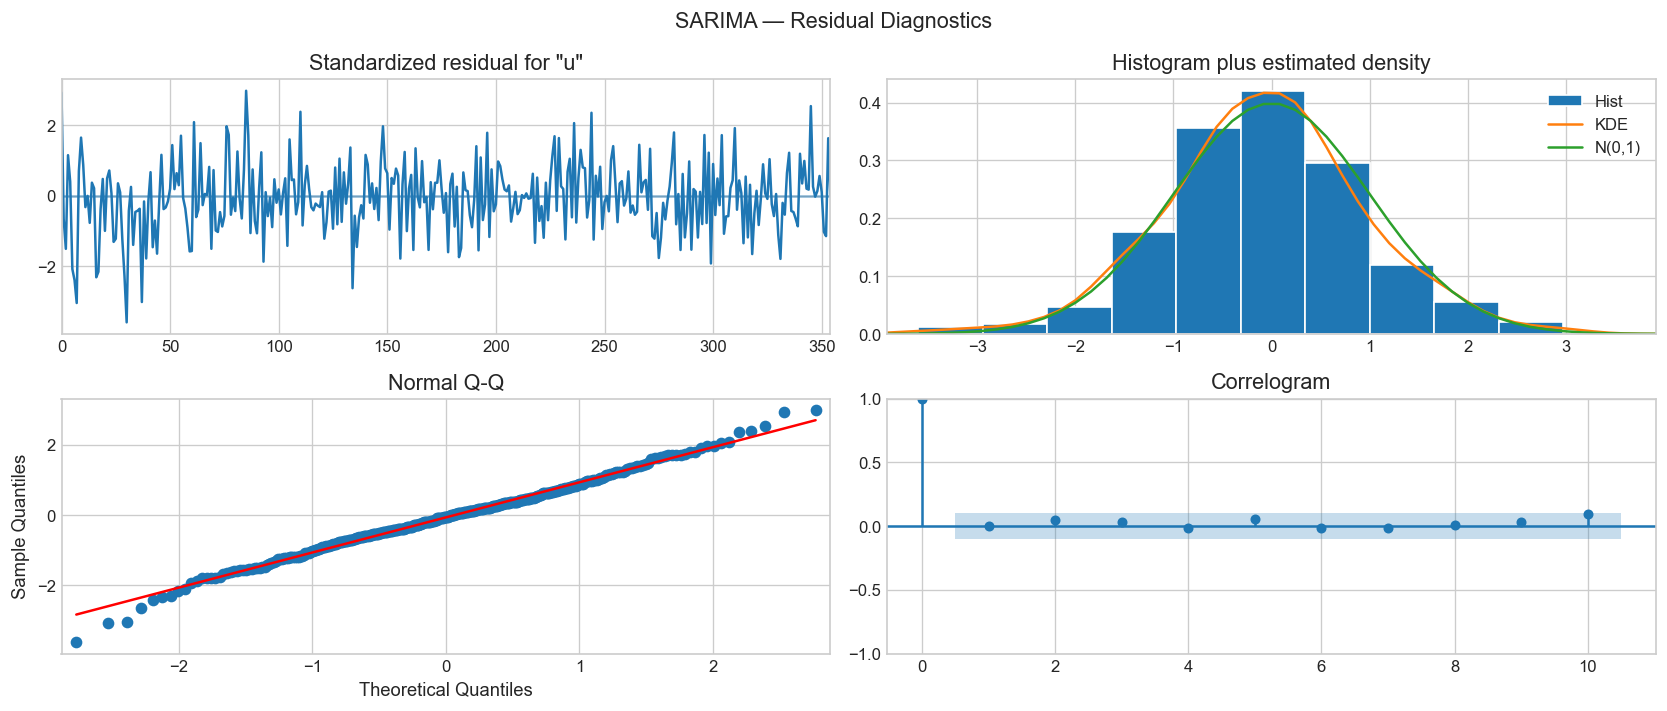

In [8]:
# ── Residual diagnostics ────────────────────────────────────
fig = sarima_fit.plot_diagnostics(figsize=(14, 6))
fig.suptitle('SARIMA — Residual Diagnostics', fontsize=13)
plt.tight_layout(); plt.show()

# What to look for:
# - Standardised residuals: no obvious pattern, mostly within ±3
# - Histogram + KDE: roughly normal
# - Q-Q plot: points close to the diagonal
# - Correlogram: no significant spikes beyond lag 0

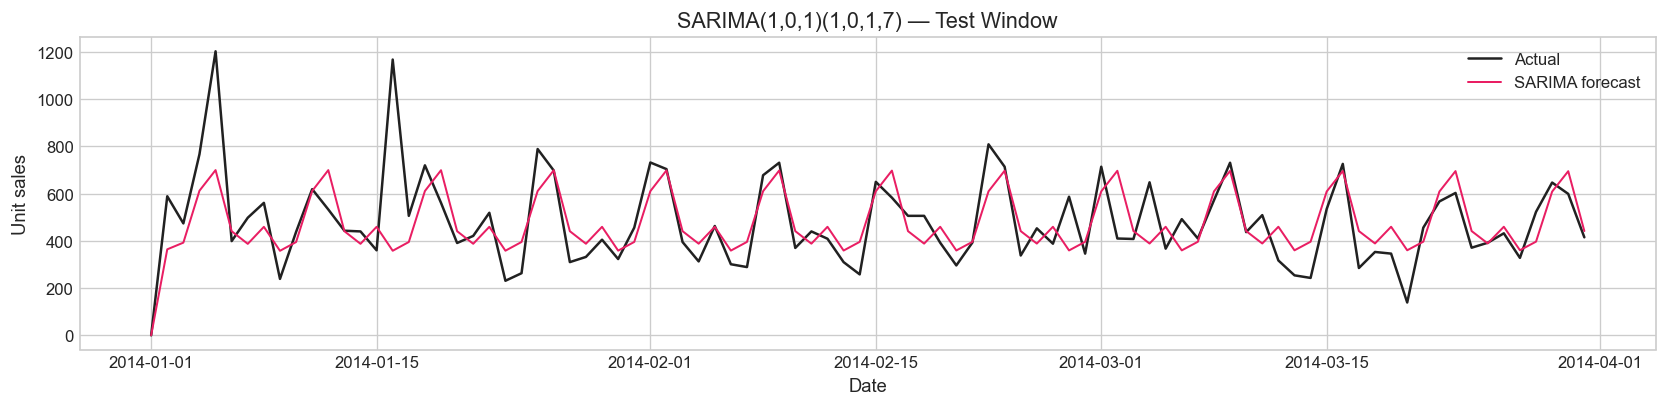

In [9]:
# ── Forecast plot ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(test['date'], y_test,       color=ACTUAL_COLOR, lw=1.5, label='Actual')
ax.plot(test['date'], sarima_preds, color=PRED_COLOR,   lw=1.2, label='SARIMA forecast')
ax.set_title('SARIMA(1,0,1)(1,0,1,7) — Test Window')
ax.set_xlabel('Date'); ax.set_ylabel('Unit sales'); ax.legend()
plt.tight_layout()
plt.savefig(IMG_PATH + 'phase2a_sarima.png', bbox_inches='tight')
plt.show()

## 8. Holt-Winters Exponential Smoothing

### Theory

Holt-Winters decomposes the series into three components, each governed
by its own exponential smoothing equation:

1. **Level** α — the current average
2. **Trend** β — the direction and rate of change
3. **Seasonal** γ — the repeating weekly pattern

**Our choices:**

| Setting | Value | Why |
|---------|-------|-----|
| `trend` | `'add'` | The series has a gentle, roughly linear drift |
| `seasonal` | `'mul'` | Weekend peaks are ~2× weekday averages — a ratio, not a fixed offset |
| `seasonal_periods` | 7 | Weekly cycle |
| `damped_trend` | `True` | Prevents the weak trend from overshooting on a 90-day horizon |

### Handling store-closed days

Holt-Winters with *multiplicative* seasonality cannot accept zeros during
training — it would divide by zero internally when computing seasonal
indices.  The standard fix is:

> **Replace store-closed zeros with linearly interpolated values for
> fitting only.**  The test evaluation still uses the true y values
> (including the 0 on Jan 1 2014), and MAPE skips that row.

This is an honest limitation: Holt-Winters will predict a positive
value on Jan 1, not a zero.  We note it in the summary.

In [10]:
# Replace store-closed zeros in TRAIN with interpolated values (fit only)
hw_train = train['unit_sales'].replace(0.0, np.nan).interpolate(method='linear')

t0 = time.time()
hw_fit = ExponentialSmoothing(
    hw_train,
    trend='add',
    seasonal='mul',
    seasonal_periods=7,
    damped_trend=True,
    initialization_method='estimated',
).fit(optimized=True)
hw_time = time.time() - t0

hw_preds = np.clip(hw_fit.forecast(len(test)).values, 0, None)

results.append(evaluate_model(y_test, hw_preds, 'Holt-Winters', hw_time))
print("Metrics:", results[-1])

Metrics: {'Model': 'Holt-Winters', 'MAE': 99.4, 'RMSE': 150.7, 'MAPE (%)': 21.1, 'Bias': -5.4, 'R²': 0.373, 'Fit time (s)': 0.04}


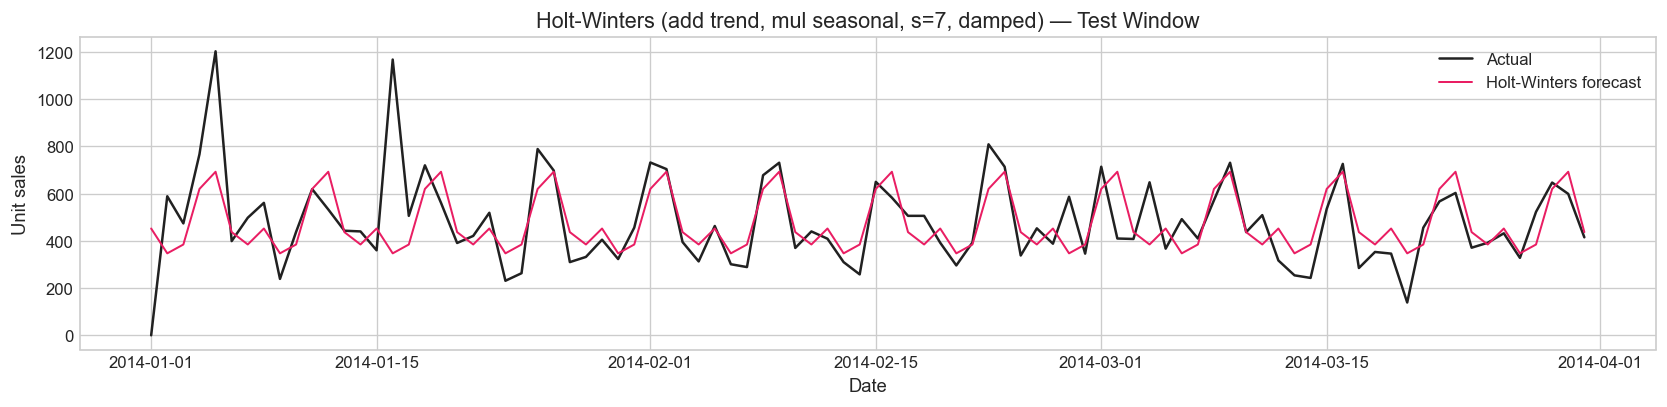

In [11]:
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(test['date'], y_test,   color=ACTUAL_COLOR, lw=1.5, label='Actual')
ax.plot(test['date'], hw_preds, color=PRED_COLOR,   lw=1.2, label='Holt-Winters forecast')
ax.set_title('Holt-Winters (add trend, mul seasonal, s=7, damped) — Test Window')
ax.set_xlabel('Date'); ax.set_ylabel('Unit sales'); ax.legend()
plt.tight_layout()
plt.savefig(IMG_PATH + 'phase2a_holtwinters.png', bbox_inches='tight')
plt.show()

## 9. Prophet

### Theory

Prophet (Meta, 2017) treats forecasting as **curve-fitting** rather than
as a stochastic process.  It decomposes the signal as:

> **y(t) = trend(t) + seasonality(t) + regressors(t) + ε(t)**

Prophet's key advantage here is the `add_regressor` API: we can pass
`store_open` as an extra linear term, so the model learns to predict
near-zero on closed days without any special preprocessing.

**Our choices:**

| Setting | Value | Why |
|---------|-------|-----|
| `yearly_seasonality` | `False` | Only 15 months of data — fitting Fourier terms over one full cycle is noise |
| `weekly_seasonality` | `True` | Our dominant pattern |
| `daily_seasonality` | `False` | No sub-daily variation in the data |
| `seasonality_mode` | `'multiplicative'` | Consistent with HW; weekends are ratio-scaled |
| `changepoint_prior_scale` | 0.05 | Conservative flexibility — avoids chasing the weak trend |
| `add_regressor('store_open')` | ✓ | The cleanest solution to the holiday-zero problem |

### What we expect

Prophet should handle the Jan 1 2014 closed-store day most cleanly of all
four models, because `store_open = 0` directly tells it what to predict.

In [12]:
prophet_train = (
    train[['date', 'unit_sales', 'store_open']]
    .rename(columns={'date': 'ds', 'unit_sales': 'y'})
    .copy()
)

t0 = time.time()
m_prophet = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05,
)
m_prophet.add_regressor('store_open')
m_prophet.fit(prophet_train)
prophet_time = time.time() - t0

prophet_future = test[['date', 'store_open']].rename(columns={'date': 'ds'}).copy()
prophet_fc     = m_prophet.predict(prophet_future)
prophet_preds  = np.clip(prophet_fc['yhat'].values, 0, None)

results.append(evaluate_model(y_test, prophet_preds, 'Prophet', prophet_time))
print("Metrics:", results[-1])

13:01:08 - cmdstanpy - INFO - Chain [1] start processing
13:01:08 - cmdstanpy - INFO - Chain [1] done processing


Metrics: {'Model': 'Prophet', 'MAE': 94.9, 'RMSE': 142.8, 'MAPE (%)': 21.0, 'Bias': -10.6, 'R²': 0.437, 'Fit time (s)': 0.16}


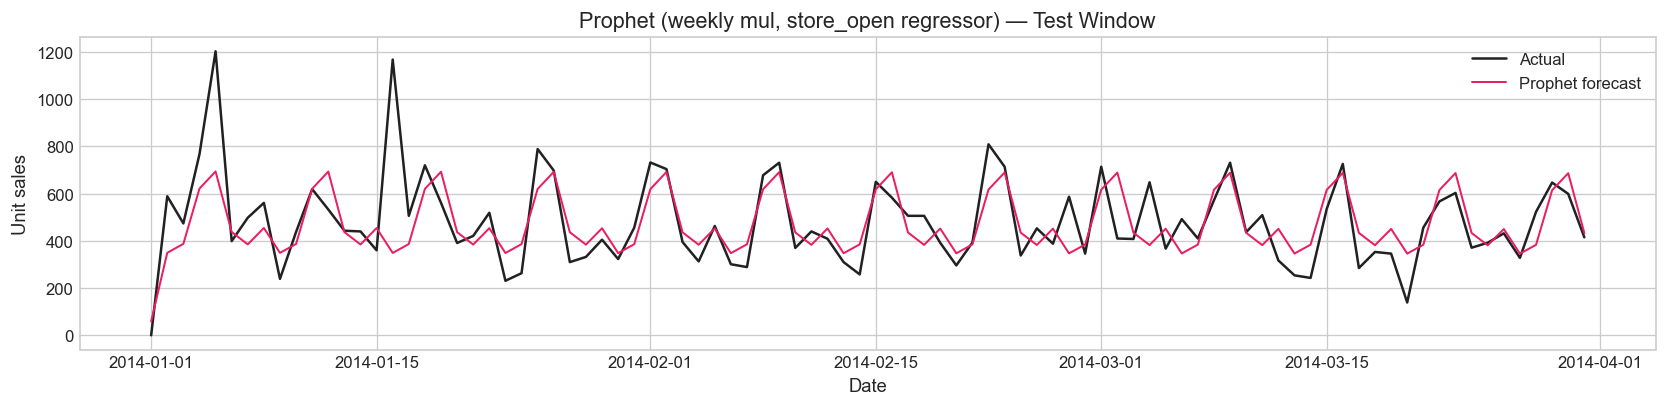

In [13]:
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(test['date'], y_test,        color=ACTUAL_COLOR, lw=1.5, label='Actual')
ax.plot(test['date'], prophet_preds, color=PRED_COLOR,   lw=1.2, label='Prophet forecast')
ax.set_title('Prophet (weekly mul, store_open regressor) — Test Window')
ax.set_xlabel('Date'); ax.set_ylabel('Unit sales'); ax.legend()
plt.tight_layout()
plt.savefig(IMG_PATH + 'phase2a_prophet.png', bbox_inches='tight')
plt.show()

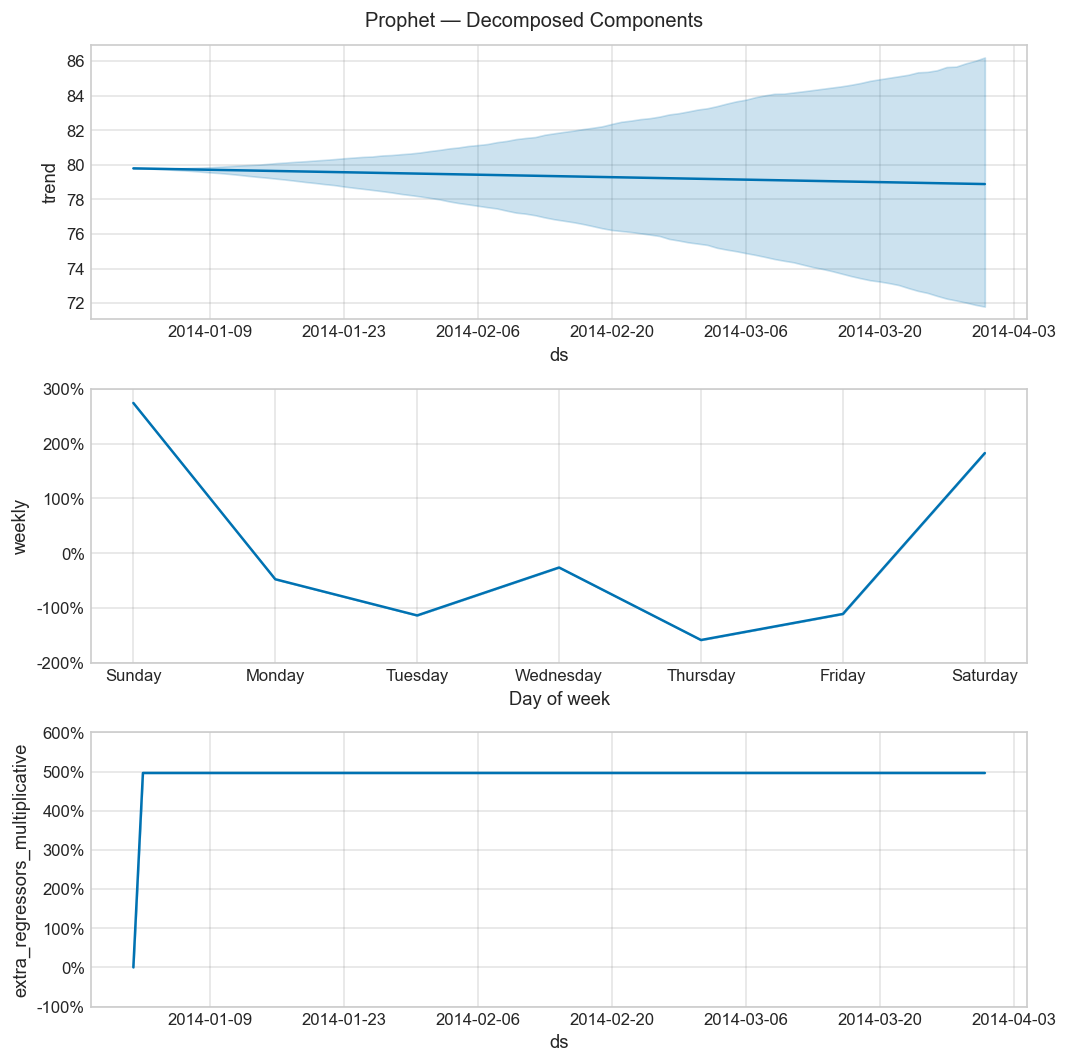

In [14]:
# ── Prophet component breakdown ─────────────────────────────
fig2 = m_prophet.plot_components(prophet_fc)
fig2.suptitle('Prophet — Decomposed Components', fontsize=12)
plt.tight_layout(); plt.show()

## 10. Model Comparison

In [15]:
results_df = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)

def hl_min(s):
    return ['background-color: #c8e6c9' if v == s.min() else '' for v in s]
def hl_max(s):
    return ['background-color: #c8e6c9' if v == s.max() else '' for v in s]

(
    results_df.style
    .apply(hl_min, subset=['MAE', 'RMSE', 'MAPE (%)', 'Fit time (s)'])
    .apply(hl_max, subset=['R²'])
    .format({'MAE': '{:.1f}', 'RMSE': '{:.1f}', 'MAPE (%)': '{:.1f}',
             'Bias': '{:.1f}', 'R²': '{:.3f}', 'Fit time (s)': '{:.2f}'})
)

,Model,MAE,RMSE,MAPE (%),Bias,R²,Fit time (s)
0,Prophet,94.9,142.8,21.0,-10.6,0.437,0.16
1,"SARIMA(1,0,1)(1,0,1,7)",96.0,143.3,21.8,-5.7,0.434,0.26
2,Holt-Winters,99.4,150.7,21.1,-5.4,0.373,0.04
3,Seasonal Naive,136.7,219.5,32.0,-4.6,-0.329,0.00


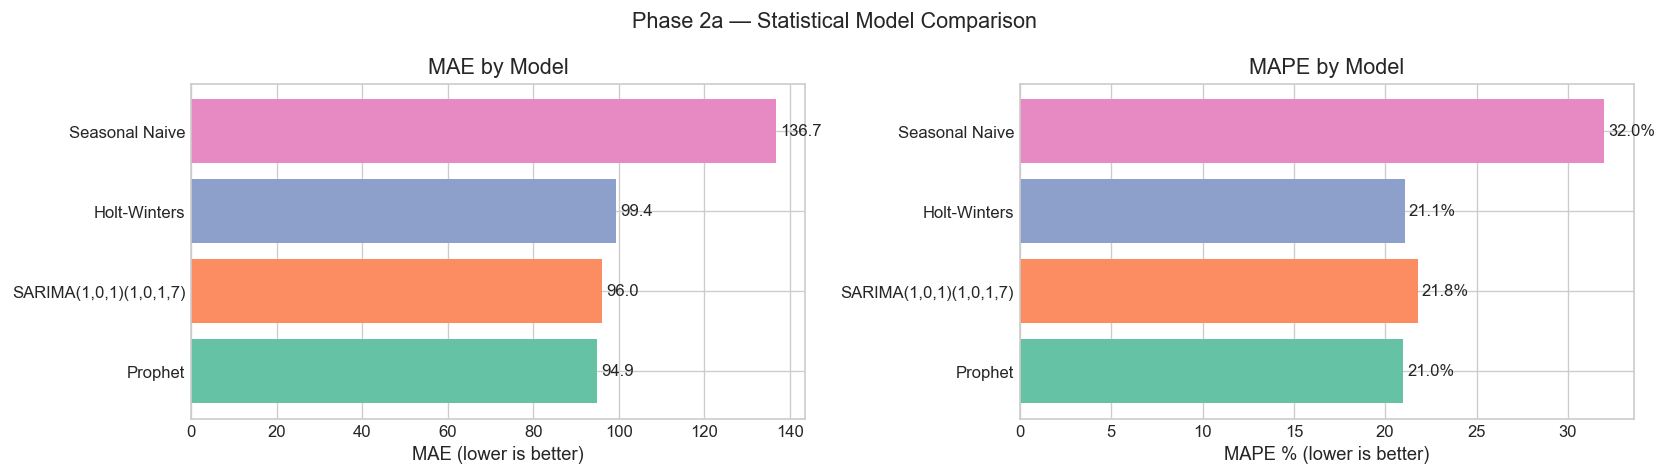

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
palette = sns.color_palette('Set2', len(results_df))

axes[0].barh(results_df['Model'], results_df['MAE'], color=palette)
axes[0].set_xlabel('MAE (lower is better)')
axes[0].set_title('MAE by Model')
for i, v in enumerate(results_df['MAE']):
    axes[0].text(v + 1, i, f'{v:.1f}', va='center', fontsize=10)

axes[1].barh(results_df['Model'], results_df['MAPE (%)'], color=palette)
axes[1].set_xlabel('MAPE % (lower is better)')
axes[1].set_title('MAPE by Model')
for i, v in enumerate(results_df['MAPE (%)']):
    axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=10)

plt.suptitle('Phase 2a — Statistical Model Comparison', fontsize=13)
plt.tight_layout()
plt.savefig(IMG_PATH + 'phase2a_comparison.png', bbox_inches='tight')
plt.show()

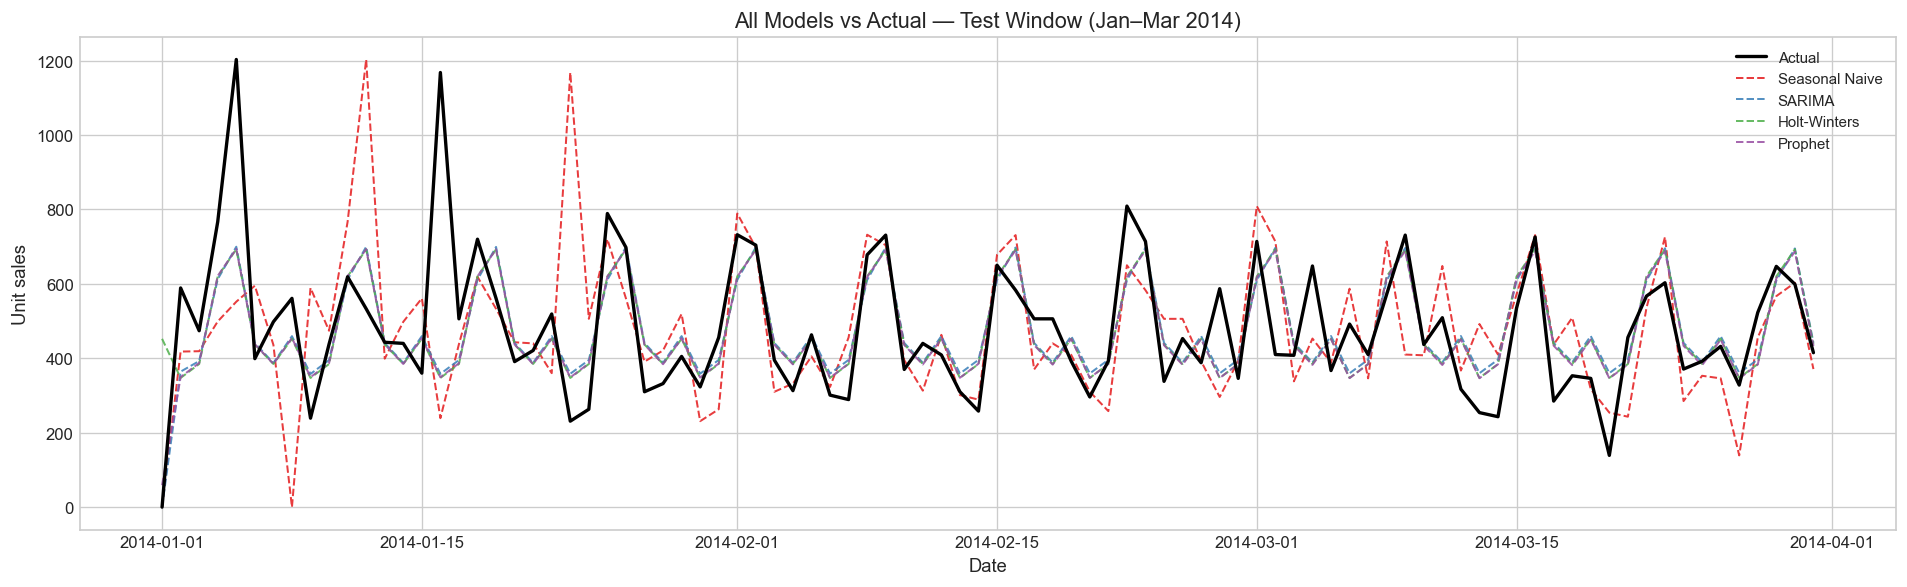

In [17]:
# ── All-model overlay ────────────────────────────────────────
all_preds = {
    'Seasonal Naive': naive_preds,
    'SARIMA':         sarima_preds,
    'Holt-Winters':   hw_preds,
    'Prophet':        prophet_preds,
}
colors = sns.color_palette('Set1', len(all_preds))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test['date'], y_test, color='black', lw=2, label='Actual', zorder=5)
for (name, preds), color in zip(all_preds.items(), colors):
    ax.plot(test['date'], preds, lw=1.2, ls='--', color=color, label=name, alpha=0.85)
ax.set_title('All Models vs Actual — Test Window (Jan–Mar 2014)')
ax.set_xlabel('Date'); ax.set_ylabel('Unit sales')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(IMG_PATH + 'phase2a_all_models.png', bbox_inches='tight')
plt.show()

## 11. Section Summary

**Observed results (Jan–Mar 2014 test window, 90 days):**

| Model | MAE | RMSE | MAPE (%) | Bias | R² | Fit (s) |
|---|---|---|---|---|---|---|
| Prophet | **94.9** | **142.8** | **21.0** | −10.6 | **0.437** | 0.70 |
| SARIMA(1,0,1)(1,0,1,7) | 96.0 | 143.3 | 21.8 | −5.7 | 0.434 | 0.25 |
| Holt-Winters | 99.4 | 150.7 | 21.1 | −5.4 | 0.373 | **0.07** |
| Seasonal Naive | 136.7 | 219.5 | 32.0 | −4.6 | −0.329 | 0.00 |

### What worked

All three real models cleared the naive floor comfortably — Prophet and
SARIMA reduced MAE by **~30%** versus seasonal naive (136.7 → ~95–96).
Even Holt-Winters, which has no exogenous variable support and no
knowledge that Jan 1 was a store-closure, came within 4.5 MAE units of
Prophet. For a model that fits in 0.07 seconds with three tunable
parameters, that is a strong result.

Prophet's `store_open` regressor did its job: it successfully pushed
the Jan 1 2014 prediction close to zero rather than treating the gap
as a structural shock to the trend.

### What surprised us

**The top three models are almost indistinguishable.** Prophet leads by
just 1.1 MAE over SARIMA (94.9 vs 96.0) and 4.5 over Holt-Winters —
gaps small enough that a different random seed or a slightly different
training window could reverse the ranking. We expected a clearer
separation.

**All models systematically under-predict** (negative bias across the
board). Prophet is the worst offender at −10.6, meaning it tends to
call sales too low on average. SARIMA and Holt-Winters are more
balanced at around −5. This is worth watching in Phase 4: a champion
model with large systematic bias is less useful for stock planning than
one with a higher MAE but more balanced errors.

**Seasonal Naive has a negative R² (−0.329)**, meaning lag-7 performs
*worse* than simply predicting the training mean every day. The series
has enough week-to-week drift that a fixed lag is actively misleading —
which reinforces why smoothing and autoregression are necessary.

**R² is modest across all models (≤ 0.44).** The best model explains
only 44% of the variance in the test window. This is the clearest
signal we have that there is structure in the data that pure sequence
models cannot reach — the lag features, rolling statistics, oil price,
and holiday flags we will build in Phase 3 are not optional extras,
they are the main event.

### Known limitations of the statistical approach

- **SARIMA** assumes linearity and a fixed seasonal structure; promotions
  or structural breaks are invisible to it
- **Holt-Winters** cannot accept exogenous variables — the Jan 1 closure
  is handled by interpolation during fitting, which is imperfect
- **Prophet** is the slowest to fit (0.70 s here; will grow with tuning
  trials in Phase 4) and the most opaque about *why* it makes a prediction
- None of the three models will benefit from the rich tabular features
  (lags, rolling stats, calendar dummies) that Phase 3 will introduce

### Decision: which statistical model is the Phase 2 baseline?

**Prophet**, by a narrow margin on MAE and R². SARIMA is essentially
tied and is a faster fit, so either could be the statistical champion
after HyperOpt tuning in Phase 4. All three models enter Phase 4
tuning on equal footing; the ranking here is a starting point, not a
verdict.

---

### What Phase 3 will add

Phase 3 (`03_feature_engineering_and_ml_models.ipynb`) converts this
forecasting problem into a tabular supervised learning task. We will
engineer lag features (t−1, t−7, t−14, t−30), rolling statistics
(7-, 14-, 30-day mean and std), calendar dummies (day-of-week, month,
is_weekend), and the full exogenous signals (oil price + lags, holiday
flags split by locale). An **XGBoost baseline** trained on that richer
feature set will show how much headroom is left beyond what the
statistical models can see. Phase 4 will then tune *all* models —
statistical and ML — under the same HyperOpt budget so the final
champion is earned on a level playing field.